<a href="https://colab.research.google.com/github/raisa1521/Hands-on-Machine-Learning/blob/main/4%EC%9E%A5_%EB%AA%A8%EB%8D%B8%20%ED%9B%88%EB%A0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**4장 모델 훈련**

###**4.1 선형 회귀**

선형 모델 -> 입력 특성의 가중치 합과 편향이라는 상수를 더해 예측을 만든다.

-선형회귀모델의 예측-

$$
\hat{y}=\theta_0+\theta_1x_1+\theta_2x_2+\cdots+\theta_nx_n
$$

- $\hat{y}$은 예측값
- $n$은 특성의 수
- $x_i$는 $i$번째 특성값
- $\theta_j$는 $j$번째 모델 파라미터
  편향 $\theta_0$과 특성의 가중치 $\theta_1,\theta_2,\cdots,\theta_n$을 포함

-선형회귀모델의 예측(벡터형태)-

$$
\hat{y}=h_\theta(\mathbf{x})=\theta \cdot \mathbf{x}
$$

- $h_\theta$는 모델 파라미터 $\theta$를 사용한 가설 함수
- $\theta$는 편향 $\theta_0$과 $\theta_1$에서 $\theta_n$까지의 특성 가중치를 담은 모델의 파라미터 벡터
- $\mathbf{x}$는 $x_0$에서 $x_n$까지 담은 샘플의 특성 벡터
  $x_0$은 항상 1
- $\theta \cdot \mathbf{x}$는 벡터 $\theta$와 $\mathbf{x}$의 점곱

-선형 회귀 모델의 MSE 비용 함수-


$$
\mathrm{MSE}(\mathbf{X},h_\theta)
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\theta^T \mathbf{x}^{(i)}-y^{(i)}
\right)^2
$$

모델이 파라미터 벡터 $\theta$를 가진다는 것을 명확히 하려고 $h$ 대신 $h_\theta$를 사용한 것

####**4.1.1 정규방정식**

-정규 방정식-

$$
\hat{\theta}
=
\left(\mathbf{X}^{T}\mathbf{X}\right)^{-1}
\mathbf{X}^{T}\mathbf{y}
$$

- $\hat{\theta}$은 비용 함수를 최소화하는 $\theta$ 값
- $\mathbf{y}$는 $y^{(1)}$부터 $y^{(m)}$까지 포함하는 타깃 벡터

In [9]:
#위 공식을 테스트 하기 위한 선형처럼 보이는 데이터 생성
import numpy as np

np.random.seed(42) #동일하게 재현되도록 시드 지정
m =100 #샘플 개수
X=2*np.random.rand(m, 1) #열 벡터
y=4+3*X+np.random.randn(m,1) #열 벡터

In [10]:
#넘파이 선형대수 모듈 (np.linage)에 있는 inv() 함수를 사용해 역행렬을 계산하고 dot()을 사용해 행렬 곱셈
from sklearn.preprocessing import add_dummy_feature
X_b=add_dummy_feature(X) #각 샘플의 x0=1을 추가
theta_best = np.linalg.inv(X_b.T @ X_b)@X_b.T@y #@연산자는 행렬곱셉 수

In [11]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [12]:
#theta을 사용해 예측
X_new=np.array([[0], [2]])
X_new_b=add_dummy_feature(X_new)
y_predict = X_new_b@theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

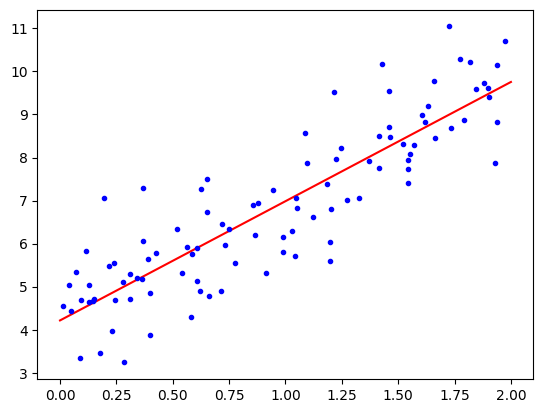

In [13]:
#모델의 예측을 그래프로 나타내기
import matplotlib.pyplot as plt
plt.plot(X_new, y_predict, "r-", label="예측")
plt.plot(X, y, "b.")
[...] #레이블,축,그리드,범례를 추가
plt.show()

In [14]:
#사이킷런에서 선형회귀 수행
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [15]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

-->사이킷런은 특성의 가중치와 편향을 분리해서 저장. LinearRegression 클래스는 scipy.linalg.lstsq()를 기반으로.

In [16]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

- $X^{+}$는 X의 유사역행렬  
- np.linalg.pinv() 함수를 사용해 유사역행렬 구

In [17]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체 = 특잇값 분해(SVD) = 표준행렬분해기법



####**4.1.2 계산복잡도**

정규 방정식은 X^TX의 역행렬을 계산

##**4.2 경사하강법**




- 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘 -> 비용 함수를 최소화하기 위해 반복해서 파라미터를 조정

- 랜덤초기화 = $\theta$를 임의의 값으로 시작
- 하이퍼 파라미터 스텝 = 가중치(Weight)를 업데이트할 때 적용하는 이동 보폭 - 학습률 하이퍼파라미로 결정

-학습률이 너무 크거나 작으면 적절한 해결법을 찾지 못함.
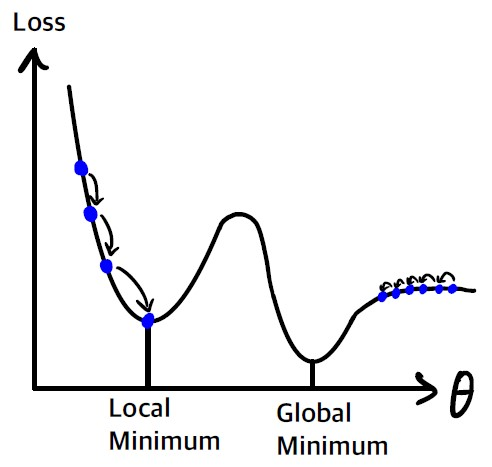

###**4.2.1 배치경사하강법**


편도함수 : 각 모델 파라미터 $\theta_j$에 대해 함수의 그레디언트를 계산해야함(=$\theta_j$가 조금씩 변경될 떄 비용함수가 얼마나 바뀌는지 계산)

$$\frac{\partial}{\partial \theta_j} MSE(\theta) = \frac{2}{m} \sum_{i=1}^{m} \left( \theta^T X^{(i)} - y^{(i)} \right) x_j^{(i)}$$

비용함수의 그레이디언트 벡터  
$$\nabla_{\theta} MSE(\theta) = \begin{bmatrix} \frac{\partial}{\partial \theta_0} MSE(\theta) \\ \frac{\partial}{\partial \theta_1} MSE(\theta) \\ \vdots \\ \frac{\partial}{\partial \theta_n} MSE(\theta) \end{bmatrix} = \frac{2}{m} X^T (X\theta - y)$$

경사하강법의 스텝  
$$\theta^{(\text{next step})} = \theta - \eta \nabla_{\theta} MSE(\theta)$$  


In [18]:
#경사하강법 스텝
eta=0.1 #학습률
n_epochs=1000
m=len(X_b) #샘플 개수

np.random.seed(42)
theta = np.random.randn(2,1) #모델 파라미터를 랜덤하게 초기화

for epoch in range(n_epochs):
  gradients=2/m*X_b.T@(X_b@theta-y)
  theta=theta-eta*gradients

에포크 : 훈련세트를 한번 반복하는 것

In [19]:
theta

array([[4.21509616],
       [2.77011339]])

###4.2.2 확률적 경사하강법


확률적 경사하강법 : 매 스텝에서 한 개의 갬플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그레디언트를 계산

장점 - 반복해서 다뤄야할 데이터가 적어져서 알고리즘이 빠르고 큰 훈련세트도 훈련 가능

단점 - 불안정 -> 해결법 : 담금질 기

In [20]:
# 학습 스케줄을 사용한 확률적 경사 하강법
n_epochs = 50
t0, t1= 5, 50 #학습스케줄 하이퍼파라미터
def learning_schedule(t):
  return t0 / (t+t1)

np.random.seed(42)
theta=np.random.randn(2,1) #랜점 초기화

for epoch in range(n_epochs):
  for iteration in range(m):
    random_index = np.random.randint(m)
    xi =X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2*xi.T@(xi@theta-yi) #SGD의 경우 m으로 나누지 않음
    eta = learning_schedule(epoch*m+iteration)
    theta = theta-eta*gradients

In [21]:
theta

array([[4.21076011],
       [2.74856079]])

In [22]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) #fit()이 1D타깃을 기대하기 때문에 y.ravel()을 씀

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [23]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

###4.2.3 미니 배치 경사하강법
: 임의의 작은 샘플 세트에 대해 그레디언트를 계산

장점 - 행렬계산에 최적화 된 하드웨어, 특히 gpu를 사용해서 성능을 향상시킬 수 있음

단점 - 지역 최솟값에서 빠져나오기 힘들 수 있음

--선형회귀 사용한 알고리즘 비교--

| 알고리즘 | \(m\)이 작을 때 | 외부 메모리 학습 지원 | \(n\)이 클 때 | 하이퍼파라미터 수 | 스케일 조정 필요 | 사이킷런 |
|---|---|---|---|---:|---|---|
| 정규방정식 | 빠름 | No | 느림 | 0 | No | N/A |
| SVD | 빠름 | No | 느림 | 0 | No | `LinearRegression` |
| 배치 경사하강법 | 느림 | No | 빠름 | 2 | Yes | N/A |
| 확률적 경사하강법 | 빠름 | Yes | 빠름 | 2개 이상 | Yes | `SGDRegressor` |
| 미니배치 경사하강법 | 빠름 | Yes | 빠름 | 2개 이상 | Yes | N/A |

##4.3 다항회귀

: 확장된 특성을 포함한 데이터셋에 선형 모델을 훈련시키는 것

In [24]:
#2차방정식에 약간의 잡음을 추가한 비선형 데이터 생성
np.random.seed(42)
m=100
X=6*np.random.rand(m,1)-3
y=0.5*X**2+X+2+np.random.randn(m,1)

In [25]:
#PolynomialFeatures를 사용해 훈련 데이터 변환
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly=poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [26]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [27]:
# LinearRegression 적용
lin_reg=LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

##4.4 학습곡선

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

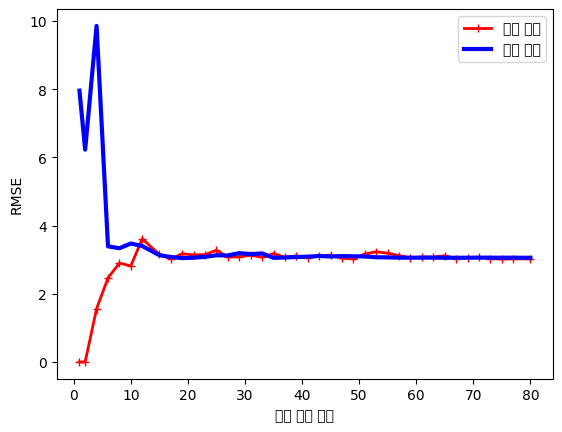

In [28]:
#선형회귀모델의 학습 곡선 살피기
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X, y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_mean_squared_error")

train_errors=-train_scores.mean(axis=1)
valid_errors=-valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="훈련 오차")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="검증 오차")
plt.xlabel("훈련 세트 크기") #레이블, 축, 그리드, 범례 추가
plt.ylabel("RMSE")
plt.legend()
plt.show()

-> 이 모델은 과소 적합 - 훈련오차와 검증오차 때문

/tmp/ipykernel_1373/1904542285.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

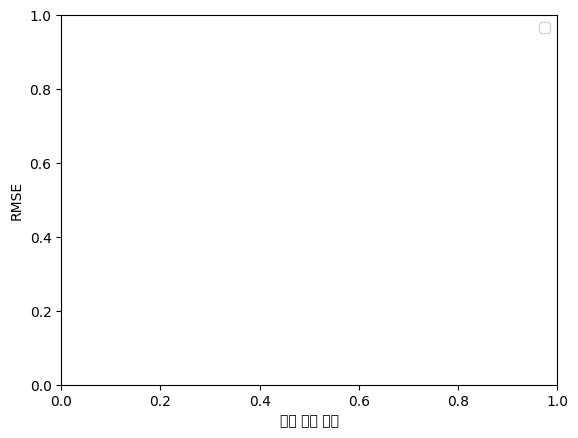

In [29]:
#10차 다항회귀 모델 학습 곡선을 그리기
from sklearn.pipeline import make_pipeline

polynomial_regression=make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression()
)

train_sizes, train_scores, vaild_scores = learning_curve(
    polynomial_regression,
    X, y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_mean_squared_error")
plt.xlabel("훈련 세트 크기") #레이블, 축, 그리드, 범례 추가
plt.ylabel("RMSE")
plt.legend()
plt.show()

- 훈련데이터의 오차가 이전보다 나아짐.  
- 두 곡선 사이에 공간이 있음 -> 검증 데이터에서보다 훈련 데이터에서 모델이 훨씬 더 나은 성능을 보임(-> 과대적합 모델의 특징 -> 더 큰 훈련 세트를 사용)

##4.5 규제가 있는 선형 모델

과대적합을 줄이는 모델을 규제하는 것(=다항식 차수 줄이기, 가중치 제한)
- 자유도를 줄이면 데이터에 과적합되기 더 어려워짐

###4.5.1 릿지 회귀

릿지회귀 비용함수

$$J(\boldsymbol{\theta}) = \text{MSE} + \alpha \frac{1}{m} \sum_{i=1}^{n} \theta_i^2$$

 -릿지 회귀는 입력 특성의 스케일에 민감하기 떄문에, 학습 전 스케일링을 통해 데이터의 스케일을 맞춰줘야 함

**4.5.2 라쏘 회귀**

라쏘회귀 비용함수
  $$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^{n} \vert{}\theta_i\vert{}$$


  -가중치가 적은 항을 0으로 만드는 방법

In [30]:
#예시
from sklearn.linear_model import Lasso

Lasso_reg = Lasso(alpha = 0.1)
Lasso_reg.fit(X,y)
Lasso_reg.predict([[1.5]])

array([4.77621741])

**4.5.3 엘라스틱넷**
-랏지와 라쏘의 보완버

일레스틱넷 비용함수

$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + r \left( 2\alpha \sum_{i=1}^{n} \vert{}\theta_i\vert{} \right) + (1-r) \left( \frac{\alpha}{m} \sum_{i=1}^{n} \theta_i^2 \right)$$

특성 수가 훈련샘플 수보다 많거나 특성 몇개가 강하게 연관일 떄 사

In [31]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio = 0.5)
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([4.78114505])

**4.5 조기종료**

일정 시간동안 검증오차가 계속 커질때, 학습을 중지하고 최소 검증오차였던 모델 파라미터로 되돌리는 방법

**4.6 로지스틱 회귀**

특정 클래스에 속할 확률 추정할 때 사용

**4.6.2 훈련과 비용함수**

로지스틱 회귀의 경우 MSE를 사용할 수 없어서 아래 손실함수 사용


$$J(\boldsymbol{\theta}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

비용함수는 최솟값을 계산하는 해가 존재하지 않아서 경사하강법으로 주로 찾음.

**4.6.3 결정경계**

In [32]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True) #어떤 특성들을 들고있는지 담긴 정보를 로드

list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [33]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [34]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [35]:
#모델 학습

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values

y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

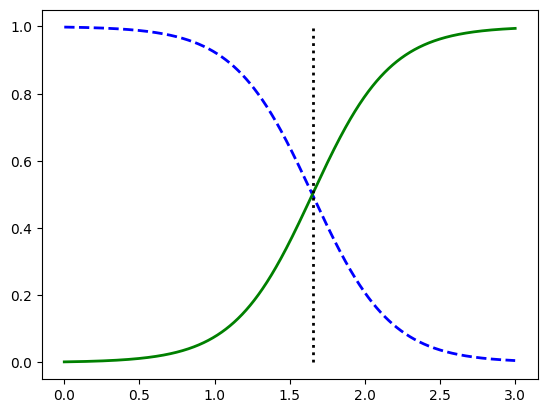

In [36]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1]>=0.5][0,0]


plt.plot(X_new, y_proba[:,0], "b--", linewidth=2, label="iris-virginica 가 아닐확률")

plt.plot(X_new, y_proba[:,1], "g-", linewidth=2, label="iris-virginic일 확률")

plt.plot([decision_boundary, decision_boundary],[0,1], "k:", linewidth=2, label='결정 경계')

plt.show()

In [37]:
print(decision_boundary)

print(log_reg.predict([[1.7], [1.5]]))

1.6516516516516517
[ True False]


**4.6.4 소프트맥스 회귀**

여러 클래스에 대한 분류를 위해 사용

샘플 주어짐->소트프맥스 회귀 모델이 클래스에 대한 점수 계산->그 점수 벡터들을 소프트맥스 함수에 넣어 클래스 확률 추정

소프트맥스회귀의 비용함수


$$J(\boldsymbol{\Theta}) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log\left(\hat{p}_k^{(i)}\right)$$

오차
 $$\text{Loss}^{(i)} = -\log\left(\hat{p}_{\text{정답}}^{(i)}\right)$$


In [38]:
X= iris.data[["petal length (cm)", "petal width (cm)"]]. values
y=iris["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [39]:
softmax_reg.predict([[5,2]])

array([2])

In [40]:
softmax_reg.predict_proba([[5,2]]).round(2)

array([[0.  , 0.04, 0.96]])